---
# LAB 5: Effective Data Visualizations
### Line charts, bar charts, heat maps, box plots

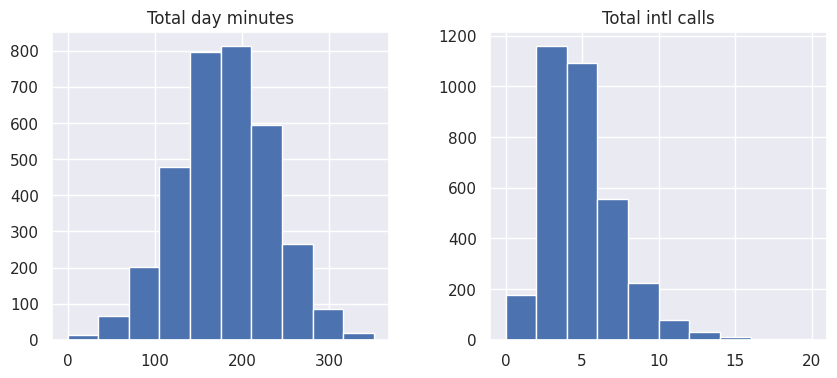

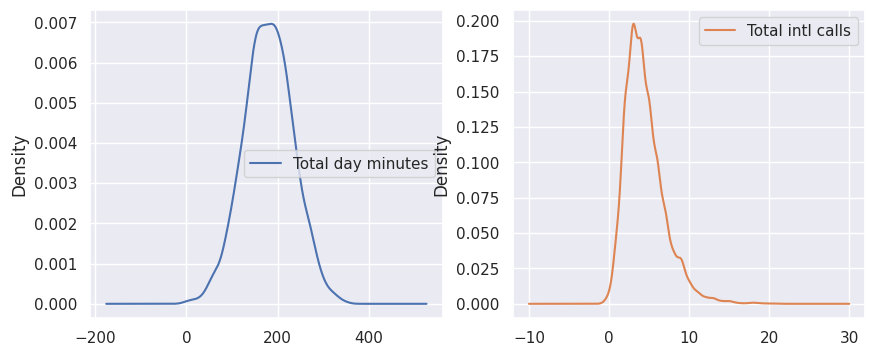

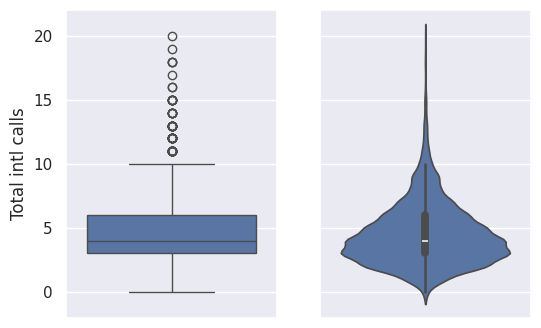

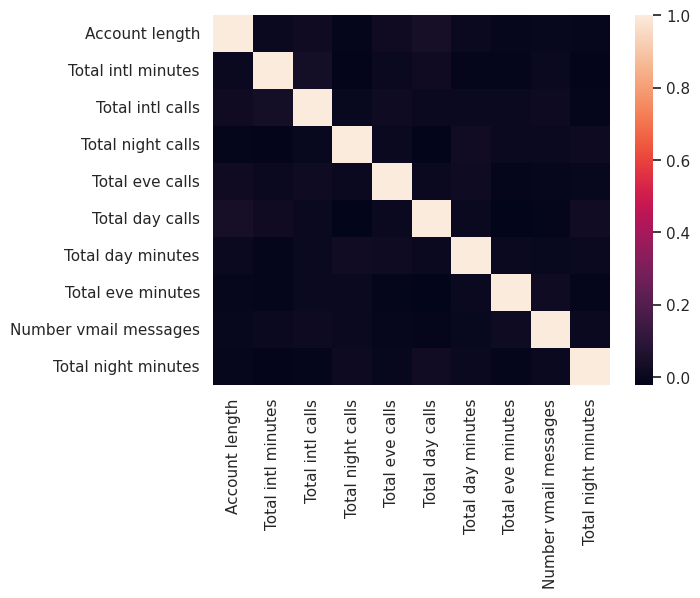

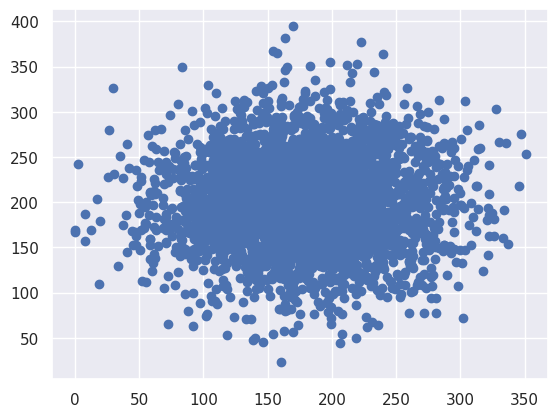

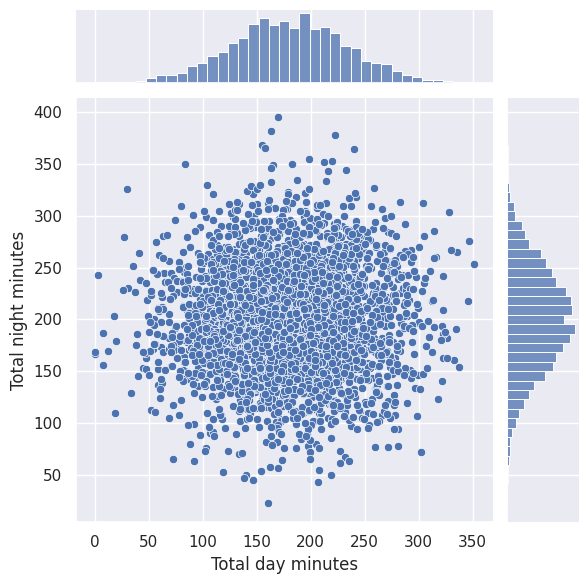

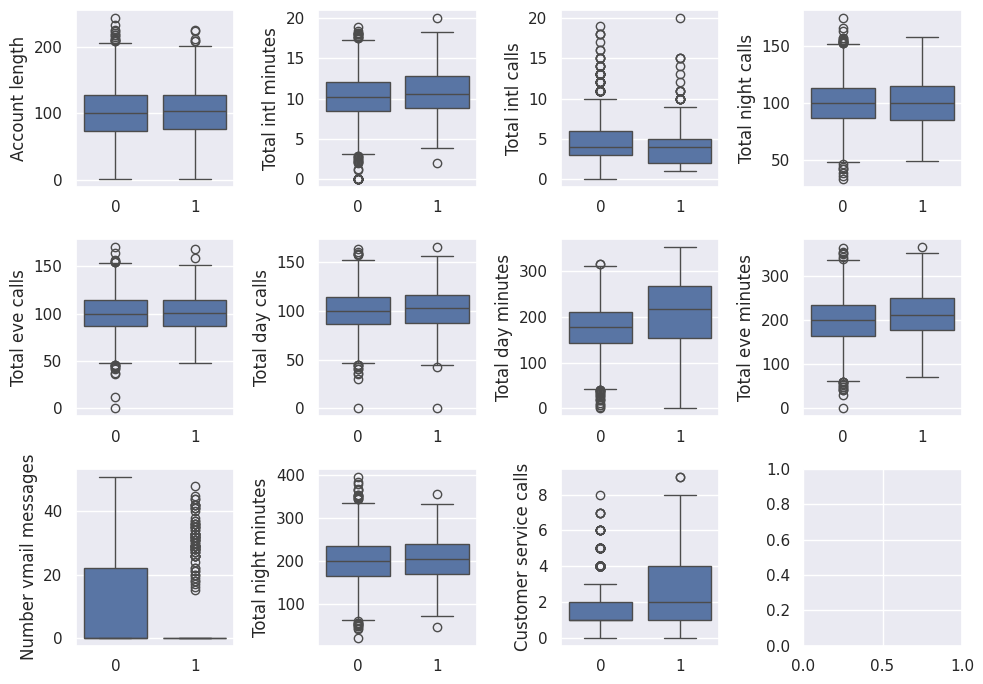

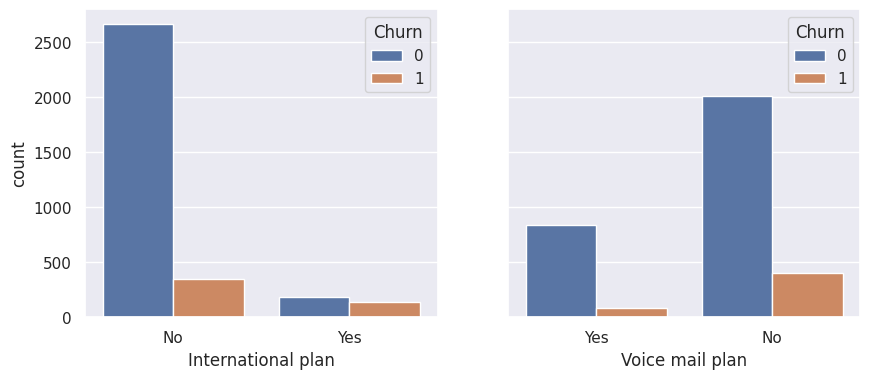

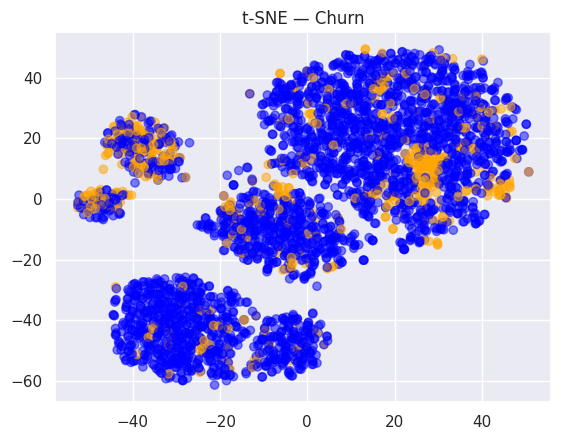

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()

DATA_URL = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"
df = pd.read_csv(DATA_URL + "telecom_churn.csv")
df["Churn"] = df["Churn"].astype("int64")
df.head()

# Histograms
selected_features = ["Total day minutes", "Total intl calls"]
df[selected_features].hist(figsize=(10, 4))
plt.show()

# Density plots
df[selected_features].plot(kind="density", subplots=True, layout=(1, 2),
                           sharex=False, figsize=(10, 4))
plt.show()

# Box plot and Violin plot
_, axes = plt.subplots(1, 2, sharey=True, figsize=(6, 4))
sns.boxplot(data=df["Total intl calls"], ax=axes[0])
sns.violinplot(data=df["Total intl calls"], ax=axes[1])
plt.show()

# Correlation Heatmap
numerical = list(
    set(df.columns)
    - set(["State", "International plan", "Voice mail plan",
           "Area code", "Churn", "Customer service calls",
           "Total day charge", "Total eve charge",
           "Total night charge", "Total intl charge"])
)
corr_matrix = df[numerical].corr()
sns.heatmap(corr_matrix)
plt.show()

# Scatter & Joint Plot
plt.scatter(df["Total day minutes"], df["Total night minutes"])
plt.show()

sns.jointplot(x="Total day minutes", y="Total night minutes", data=df, kind="scatter")
plt.show()

# Box plots for all features by Churn
numerical.append("Customer service calls")
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(10, 7))
for idx, feat in enumerate(numerical):
    ax = axes[int(idx / 4), idx % 4]
    sns.boxplot(x="Churn", y=feat, data=df, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(feat)
fig.tight_layout()
plt.show()

# Count plots
_, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
sns.countplot(x="International plan", hue="Churn", data=df, ax=axes[0])
sns.countplot(x="Voice mail plan", hue="Churn", data=df, ax=axes[1])
plt.show()

# t-SNE Visualization
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

X = df.drop(["Churn", "State"], axis=1)
X["International plan"] = X["International plan"].map({"Yes": 1, "No": 0})
X["Voice mail plan"] = X["Voice mail plan"].map({"Yes": 1, "No": 0})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(random_state=17)
tsne_repr = tsne.fit_transform(X_scaled)

plt.scatter(
    tsne_repr[:, 0], tsne_repr[:, 1],
    c=df["Churn"].map({0: "blue", 1: "orange"}),
    alpha=0.5
)
plt.title('t-SNE — Churn')
plt.show()